# 实验六之一：Kaggle LSTM 预测正弦波

本 Notebook 对应《RNN 实验》3.2 节的 Kaggle 任务：随机生成正弦波序列，用两层 `LSTMCell` 学习下一时刻的信号值，并基于 3 条已知序列向未来外推 1000 个点。

实验与课件保持一致：

- 数据：100 条、每条长度 1000，随机起点位于 `[-4T, 4T)`，`T=20`；
- 模型：`1 → LSTMCell(50) → LSTMCell(50) → Linear(1)`；
- 训练：前 3 条用于测试，其余 97 条用于训练，MSE 损失，LBFGS 优化 15 轮；
- 输出：`data.pt`、`lstm_sine_model.pth` 和 `lab6_sine_prediction.png`。

本实验不需要外部数据，也不需要开启 Kaggle GPU，新建 Notebook 后直接 **Run All** 即可。

In [1]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
DEVICE = torch.device("cpu")  # LBFGS 为全批量优化，Kaggle CPU 即可完成
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 仅供本地冒烟测试；Kaggle 默认不设置该环境变量，会使用课件的完整参数。
FAST_DEV_RUN = os.environ.get("LAB6_FAST_DEV_RUN", "0") == "1"

PERIOD_SCALE = 20
SEQUENCE_LENGTH = 160 if FAST_DEV_RUN else 1000
NUM_SEQUENCES = 12 if FAST_DEV_RUN else 100
HIDDEN_DIM = 16 if FAST_DEV_RUN else 50
EPOCHS = 1 if FAST_DEV_RUN else 15
FUTURE_STEPS = 80 if FAST_DEV_RUN else 1000
LBFGS_MAX_ITER = 2 if FAST_DEV_RUN else 20

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch:", torch.__version__)
print("设备:", DEVICE)
print("输出目录:", OUTPUT_DIR)
print("快速冒烟测试:", FAST_DEV_RUN)

PyTorch: 2.2.2
设备: cpu
输出目录: /Users/bob.li/Code/DL-ZJU/lab6-1
快速冒烟测试: False


## 1. 随机生成正弦波序列

对第 $i$ 条序列随机选择整数偏移 $s_i$，再生成

$$y_t^{(i)} = \sin\left(\frac{t+s_i}{T}\right), \quad T=20.$$

因此所有序列的频率相同，但起始相位不同。`data.pt` 保存为纯 PyTorch Tensor，可兼容新版 PyTorch 的安全加载默认值。

In [2]:
offsets = np.random.randint(
    -4 * PERIOD_SCALE,
    4 * PERIOD_SCALE,
    size=(NUM_SEQUENCES, 1),
)
time_index = np.arange(SEQUENCE_LENGTH, dtype=np.int32).reshape(1, -1)
x = time_index + offsets
data = np.sin(x / float(PERIOD_SCALE)).astype(np.float32)
data_tensor = torch.from_numpy(data)

DATA_PATH = OUTPUT_DIR / "data.pt"
torch.save(data_tensor, DATA_PATH)

assert data_tensor.shape == (NUM_SEQUENCES, SEQUENCE_LENGTH)
assert torch.isfinite(data_tensor).all()
print("数据形状:", tuple(data_tensor.shape))
print("数值范围:", (float(data_tensor.min()), float(data_tensor.max())))
print("已保存:", DATA_PATH)

plt.figure(figsize=(12, 3.5))
for index, color in zip(range(3), ["r", "g", "b"]):
    plt.plot(data[index], color, linewidth=1.5, label=f"Sequence {index}")
plt.title("Randomly generated sine-wave sequences")
plt.xlabel("Time step")
plt.ylabel("Signal value")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

数据形状: (100, 1000)
数值范围: (-0.9999902248382568, 0.999995231628418)
已保存: /Users/bob.li/Code/DL-ZJU/lab6-1/data.pt


<Figure size 1200x350 with 1 Axes>

## 2. 构建两层 LSTM 序列预测模型

每个时间步的标量 $x_t$ 先输入第一个 `LSTMCell`，其隐状态再输入第二个 `LSTMCell`，最后经过线性层得到 $\hat{x}_{t+1}$。

在已知区间内，每次输入真实的 $x_t$；预测未来时，将上一步的预测值再送回模型，进行自回归外推。

In [3]:
class Sequence(nn.Module):
    def __init__(self, hidden_dim=50):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer1 = nn.LSTMCell(1, hidden_dim)
        self.layer2 = nn.LSTMCell(hidden_dim, hidden_dim)
        self.linear = nn.Linear(hidden_dim, 1)

    def forward(self, x, future=0):
        if x.ndim != 2 or x.size(1) == 0:
            raise ValueError(f"输入应为 [batch, sequence_length] 且序列非空，实际为 {tuple(x.shape)}")

        batch_size = x.size(0)
        h_t = x.new_zeros(batch_size, self.hidden_dim)
        c_t = x.new_zeros(batch_size, self.hidden_dim)
        h_t2 = x.new_zeros(batch_size, self.hidden_dim)
        c_t2 = x.new_zeros(batch_size, self.hidden_dim)
        outputs = []

        # 用已知信号逐步预测下一时刻。
        for x_t in x.split(1, dim=1):
            h_t, c_t = self.layer1(x_t, (h_t, c_t))
            h_t2, c_t2 = self.layer2(h_t, (h_t2, c_t2))
            output = self.linear(h_t2)
            outputs.append(output)

        # 将上一步预测值作为下一步输入，自回归预测未来。
        for _ in range(future):
            h_t, c_t = self.layer1(output, (h_t, c_t))
            h_t2, c_t2 = self.layer2(h_t, (h_t2, c_t2))
            output = self.linear(h_t2)
            outputs.append(output)

        return torch.cat(outputs, dim=1)


model = Sequence(HIDDEN_DIM).to(DEVICE)
with torch.no_grad():
    probe = model(torch.zeros(2, 8, device=DEVICE), future=3)
assert probe.shape == (2, 11)
print(model)
print("形状测试:", tuple(probe.shape))
print("可训练参数:", f"{sum(p.numel() for p in model.parameters()):,}")

Sequence(
  (layer1): LSTMCell(1, 50)
  (layer2): LSTMCell(50, 50)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)
形状测试: (2, 11)
可训练参数: 31,051


## 3. 构造“当前值 → 下一时刻值”的训练样本

若原始序列为 $[x_0,x_1,\ldots,x_{999}]$，则模型输入为 $[x_0,\ldots,x_{998}]$，监督标签为向后平移一位的 $[x_1,\ldots,x_{999}]$。

In [4]:
def load_tensor_safely(path):
    try:
        return torch.load(path, map_location=DEVICE, weights_only=True)
    except TypeError:  # 兼容尚无 weights_only 参数的旧版 PyTorch
        return torch.load(path, map_location=DEVICE)


loaded_data = load_tensor_safely(DATA_PATH).to(dtype=torch.float32)
train_data = loaded_data[3:, :-1].to(DEVICE)
train_target = loaded_data[3:, 1:].to(DEVICE)
test_data = loaded_data[:3, :-1].to(DEVICE)
test_target = loaded_data[:3, 1:].to(DEVICE)

assert train_data.shape == train_target.shape
assert test_data.shape == test_target.shape
print("训练输入/标签:", tuple(train_data.shape), tuple(train_target.shape))
print("测试输入/标签:", tuple(test_data.shape), tuple(test_target.shape))

训练输入/标签: (97, 999) (97, 999)
测试输入/标签: (3, 999) (3, 999)


## 4. 使用 MSE 和 LBFGS 训练 15 轮

LBFGS 在一次 `step` 中可能多次调用 `closure`，因此 `closure` 必须完成清空梯度、前向传播、计算损失和反向传播。这里每轮优化完后再计算一次当前训练损失，使日志更清晰。

In [5]:
criterion = nn.MSELoss()
optimizer = optim.LBFGS(
    model.parameters(),
    lr=0.8,
    max_iter=LBFGS_MAX_ITER,
    history_size=10 if FAST_DEV_RUN else 100,
)
loss_history = []

model.train()
for epoch in range(1, EPOCHS + 1):
    def closure():
        optimizer.zero_grad(set_to_none=True)
        prediction = model(train_data)
        loss = criterion(prediction, train_target)
        if not torch.isfinite(loss):
            raise FloatingPointError(f"第 {epoch} 轮出现非有限损失: {loss.item()}")
        loss.backward()
        return loss

    optimizer.step(closure)
    with torch.no_grad():
        epoch_loss = criterion(model(train_data), train_target).item()
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | train MSE: {epoch_loss:.8f}")

MODEL_PATH = OUTPUT_DIR / "lstm_sine_model.pth"
torch.save(model.state_dict(), MODEL_PATH)
assert np.isfinite(loss_history).all()
print("已保存模型:", MODEL_PATH)

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Epoch 01/15 | train MSE: 0.00143358
Epoch 02/15 | train MSE: 0.00029621
Epoch 03/15 | train MSE: 0.00015123
Epoch 04/15 | train MSE: 0.00010977
Epoch 05/15 | train MSE: 0.00004845
Epoch 06/15 | train MSE: 0.00001566
Epoch 07/15 | train MSE: 0.00000815
Epoch 08/15 | train MSE: 0.00000669
Epoch 09/15 | train MSE: 0.00000629
Epoch 10/15 | train MSE: 0.00000562
Epoch 11/15 | train MSE: 0.00000450
Epoch 12/15 | train MSE: 0.00000438
Epoch 13/15 | train MSE: 0.00000438
Epoch 14/15 | train MSE: 0.00000419
Epoch 15/15 | train MSE: 0.00000415
已保存模型: /Users/bob.li/Code/DL-ZJU/lab6-1/lstm_sine_model.pth


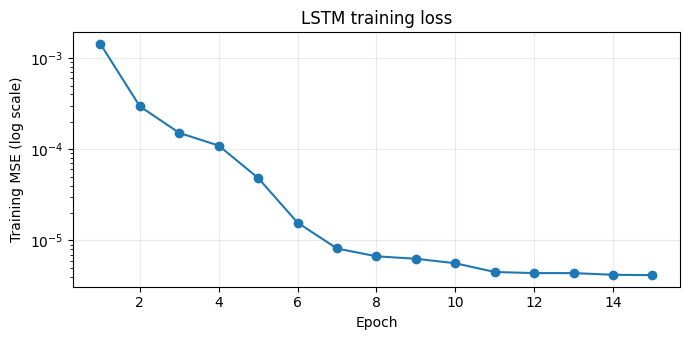

In [6]:
plt.figure(figsize=(7, 3.5))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker="o")
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Training MSE (log scale)")
plt.title("LSTM training loss")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 5. 预测已知区间并外推未来 1000 个点

实线表示对已知测试区间的下一步预测，点线表示模型自回归生成的未来信号。测试 MSE 只在存在真实标签的已知区间内计算。

已知区间 test MSE: 0.00000456
预测形状: (3, 1999)


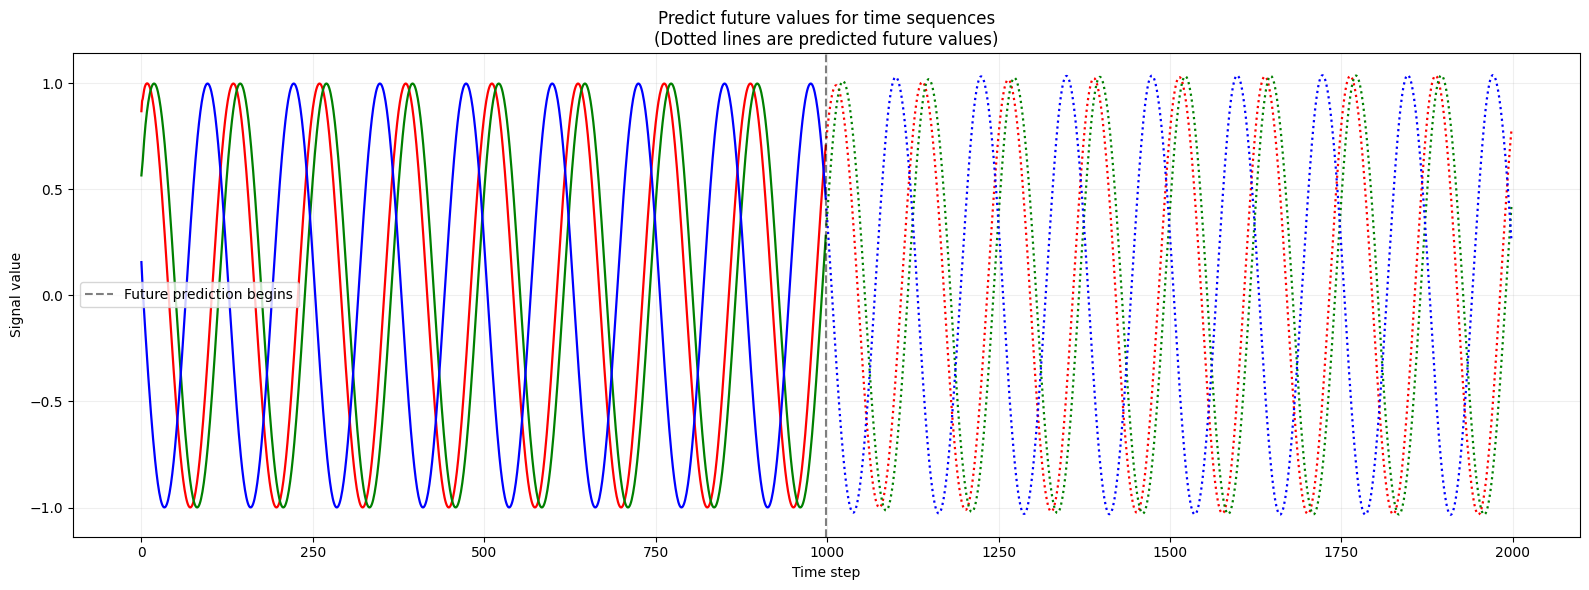

已保存预测图: /Users/bob.li/Code/DL-ZJU/lab6-1/lab6_sine_prediction.png


In [7]:
model.eval()
with torch.no_grad():
    prediction = model(test_data, future=FUTURE_STEPS)
    known_prediction = prediction[:, :-FUTURE_STEPS]
    test_loss = criterion(known_prediction, test_target).item()

expected_length = test_data.size(1) + FUTURE_STEPS
assert prediction.shape == (3, expected_length)
assert torch.isfinite(prediction).all()
print(f"已知区间 test MSE: {test_loss:.8f}")
print("预测形状:", tuple(prediction.shape))

y = prediction.cpu().numpy()
known_length = test_data.size(1)
figure_path = OUTPUT_DIR / "lab6_sine_prediction.png"

plt.figure(figsize=(16, 6))
for values, color in zip(y, ["r", "g", "b"]):
    plt.plot(
        np.arange(known_length),
        values[:known_length],
        color,
        linewidth=1.6,
    )
    plt.plot(
        np.arange(known_length, known_length + FUTURE_STEPS),
        values[known_length:],
        color + ":",
        linewidth=1.6,
    )

plt.axvline(known_length - 1, color="black", linestyle="--", alpha=0.5, label="Future prediction begins")
plt.title("Predict future values for time sequences\n(Dotted lines are predicted future values)")
plt.xlabel("Time step")
plt.ylabel("Signal value")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
plt.close()
print("已保存预测图:", figure_path)

## 6. 实验结果检查

下面单元格检查课件要求的关键配置和输出。出现全部通过的提示，即表明 Notebook 已完成数据生成、两层 LSTM 训练、测试和未来外推。

In [8]:
assert isinstance(model.layer1, nn.LSTMCell)
assert isinstance(model.layer2, nn.LSTMCell)
assert isinstance(model.linear, nn.Linear)
assert len(loss_history) == EPOCHS
assert DATA_PATH.exists()
assert MODEL_PATH.exists()
assert figure_path.exists()

if not FAST_DEV_RUN:
    assert loaded_data.shape == (100, 1000)
    assert train_data.shape == (97, 999)
    assert test_data.shape == (3, 999)
    assert HIDDEN_DIM == 50
    assert EPOCHS == 15
    assert FUTURE_STEPS == 1000

print("✅ Lab 6-1 全部检查通过")
print({
    "final_train_mse": loss_history[-1],
    "known_test_mse": test_loss,
    "prediction_shape": tuple(prediction.shape),
})

✅ Lab 6-1 全部检查通过
{'final_train_mse': 4.1538496589055285e-06, 'known_test_mse': 4.56283169114613e-06, 'prediction_shape': (3, 1999)}
